# Downscaling with UNET

In [1]:
# Load packages

from copy import deepcopy

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import OneCycleLR
import numpy as np

import json

import torch
import numpy as np
import xarray as xr
import einops
import pandas as pd

import pathlib
import sys
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime

from math import log2


import torch.nn.functional as F
from scipy.stats import gamma

import mlflow

from matplotlib.patches import Rectangle

In [2]:
# Variables stored in Kelvin that are converted to Celsius in denormalise().
_KELVIN_TARGETS = frozenset({"tasmax"})

_KELVIN_TO_CELSIUS = 273.15

class CORDEXDataset(torch.utils.data.Dataset):
    """CORDEXBench: A benchmarking dataset for regional climate downscaling.

    Supports any target variable. Two normalisation strategies are applied
    depending on the variable:

        - Variables in _LOG1P_TARGETS (e.g. pr): log1p transform to compress the
          heavy-tailed distribution, followed by a global z-score normalisation.
          The inverse transform (expm1) always returns non-negative values, which
          is physically correct for precipitation.

        - All other variables (e.g. tasmax): global z-score normalisation only.

    In both cases, normalisation statistics (mean and std) are computed globally
    over all samples and all grid cells, giving a single scalar per channel.

    Variables in _KELVIN_TARGETS (e.g. tasmax) are converted from Kelvin to
    Celsius in denormalise().

    Attributes:
        num_samples (int): Total number of samples in the dataset.
        grid_latitude_pred (xr.DataArray): Latitude coordinates of the predictors grid.
        grid_longitude_pred (xr.DataArray): Longitude coordinates of the predictors grid.
        grid_latitude_tgt (xr.DataArray): Latitude coordinates of the targets grid.
        grid_longitude_tgt (xr.DataArray): Longitude coordinates of the targets grid.
        time (pd.DatetimeIndex): Time coordinates.
        normalised_two_d_predictors (np.ndarray): Normalised 2D predictors,
            shape (num_samples, channels, lat, lon).
        normalised_one_d_predictors (np.ndarray): Normalised 1D predictors,
            shape (num_samples, num_1d_features).
        target_field (np.ndarray | None): Normalised target field,
            shape (num_samples, channels, lat, lon), or None if no target path provided.
        num_2d_predictors (int): Number of 2D predictor fields.
        num_1d_predictors (int): Number of 1D predictor variables.
    """

    def __init__(
        self,
        predictors_data_path: str,
        predictors: list[str],
        target: list[str],
        normalisation_stats_path: str | None = None,
        targets_data_path: str | None = None,
        is_train: bool = False,
    ):
        """Initialise CORDEX Benchmark dataset.

        If loading a dataset for training, normalisation statistics are computed over the
        training period and saved to a JSON file. If loading a dataset for validation or
        testing, normalisation statistics are loaded from that JSON file.

        Args:
            predictors_data_path: Path to netCDF data file for predictors.
            predictors: List of predictor field names, e.g. ["u_500", "t_850"].
            target: List of target field names, e.g. ["pr"] or ["tasmax"].
            normalisation_stats_path: Path to JSON file for storing/loading normalisation
                statistics. Required when is_train=False.
            targets_data_path: Path to netCDF data file for the target. If not provided,
                torch.tensor(float("nan")) is returned as the target from __getitem__.
            is_train: Whether the dataset is for training. If True, normalisation
                statistics are computed and saved to normalisation_stats_path.

        Raises:
            ValueError: If time coordinates do not match between predictors and targets.
            ValueError: If normalisation_stats_path is not provided when is_train=False.
            ValueError: If predictors differ from those used to compute normalisation stats.
        """
        super().__init__()

        self._target = target

        # Load predictors
        with xr.open_dataset(predictors_data_path, engine="netcdf4") as ds_pred:
            two_d_predictors = np.stack(
                [ds_pred[predictor].values for predictor in predictors], axis=-1
            )  # (sample, lat, lon, channels)
            predictors_time = ds_pred["time"]
            self.grid_longitude_pred = ds_pred["lon"]
            self.grid_latitude_pred = ds_pred["lat"]

        # Load targets
        if targets_data_path is not None:
            with xr.open_dataset(targets_data_path, engine="netcdf4") as ds_tgt:
                target_field = np.stack(
                    [ds_tgt[tgt].values for tgt in target], axis=-1
                )  # (sample, lat, lon, channels)
                targets_time = ds_tgt["time"]
                self.grid_latitude_tgt = ds_tgt["lat"]
                self.grid_longitude_tgt = ds_tgt["lon"]

            if not np.array_equal(predictors_time.values, targets_time.values):
                raise ValueError(
                    "Time coordinates do not match between predictors and targets files."
                )
        else:
            target_field = None

        self.time = pd.to_datetime(predictors_time)
        self.num_samples = two_d_predictors.shape[0]

        # ------------------------------------------------------------------ #
        # Normalise 2D predictors (per-sample spatial z-score)
        #
        # Each predictor field is normalised independently per sample by
        # subtracting its spatial mean and dividing by its spatial std. This
        # removes the day-to-day variation in large-scale state (e.g. a warm
        # vs cold day) and keeps the spatial structure, which is what the
        # model needs to learn the downscaling mapping.
        # ------------------------------------------------------------------ #
        normalised_two_d_predictors = (
            two_d_predictors - np.mean(two_d_predictors, axis=(1, 2), keepdims=True)
        ) / np.std(two_d_predictors, axis=(1, 2), keepdims=True)
        self.normalised_two_d_predictors = einops.rearrange(
            normalised_two_d_predictors, "sample lat lon channels -> sample channels lat lon"
        )
        self._num_2d_predictors = self.normalised_two_d_predictors.shape[1]

        # ------------------------------------------------------------------ #
        # Build 1D predictors
        #
        # Three sources of information are concatenated:
        #   1. Seasonal indicator: sin/cos encoding of day-of-year, giving the
        #      model a smooth, periodic representation of the seasonal cycle.
        #   2. Spatial means of each 2D predictor: the large-scale daily state
        #      that was removed by the per-sample normalisation above.
        #   3. Spatial stds of each 2D predictor: the day-to-day variability
        #      in spatial structure.
        # ------------------------------------------------------------------ #
        day_of_year = self.time.dayofyear
        seasonal_indicator = np.stack(
            [
                np.sin(2 * np.pi * day_of_year / 365),
                np.cos(2 * np.pi * day_of_year / 365),
            ],
            axis=-1,
        )  # (sample, 2)
        two_d_predictor_spatial_means = np.mean(two_d_predictors, axis=(1, 2))  # (sample, channels)
        two_d_predictor_spatial_stds = np.std(two_d_predictors, axis=(1, 2))    # (sample, channels)
        one_d_predictors = np.concatenate(
            [two_d_predictor_spatial_means, two_d_predictor_spatial_stds, seasonal_indicator],
            axis=-1,
        )  # (sample, num_1d_features)


        # Normalisation statistics (computed on train, loaded on val/test)
        if is_train:
            normalisation_stats = self._compute_normalisation_stats(
                predictors=predictors,
                one_d_predictors=one_d_predictors,
                target_field=target_field,
            )
            if normalisation_stats_path is not None:
                with open(normalisation_stats_path, "w") as f:
                    json.dump(normalisation_stats, f, indent=4)
        else:
            if normalisation_stats_path is None:
                raise ValueError(
                    "Must provide normalisation_stats_path when is_train=False."
                )
            with open(normalisation_stats_path, "r") as f:
                normalisation_stats = json.load(f)

            if normalisation_stats["metadata"]["predictors"] != predictors:
                raise ValueError(
                    f"Predictors in normalisation file "
                    f"({normalisation_stats['metadata']['predictors']}) differ from "
                    f"those requested ({predictors})."
                )

        self._normalisation_stats = normalisation_stats

        # Apply 1D predictor normalisation
        one_d_means = np.array(normalisation_stats["predictor_1d_means"])
        one_d_stds = np.array(normalisation_stats["predictor_1d_stds"])
        self.normalised_one_d_predictors = (one_d_predictors - one_d_means) / one_d_stds
        self._num_1d_predictors = self.normalised_one_d_predictors.shape[1]


        # Apply target normalisation
        self.target_field = (
            self._normalise_target(target_field, normalisation_stats)
            if target_field is not None
            else None
        )


    # Private helpers
    def _compute_normalisation_stats(
        self,
        predictors: list[str],
        one_d_predictors: np.ndarray,
        target_field: np.ndarray | None,
    ) -> dict:
        """Compute normalisation statistics over the training period.

        Global statistics (one scalar mean and std per channel) are computed
        over all samples and all grid cells. For variables in _LOG1P_TARGETS,
        the log1p transform is applied before computing stats.

        Args:
            predictors: List of predictor field names.
            one_d_predictors: shape (sample, num_1d_features).
            target_field: shape (sample, lat, lon, channels), or None.

        Returns:
            Normalisation statistics dict, ready to serialise to JSON.
        """
        stats: dict = {
            "predictor_1d_means": np.mean(one_d_predictors, axis=0).tolist(),
            "predictor_1d_stds": np.std(one_d_predictors, axis=0).tolist(),
            "metadata": {"predictors": predictors, "target": self._target},
            "target_means": {},
            "target_stds": {},
        }

        if target_field is not None:
            for ch_idx, name in enumerate(self._target):
                channel = target_field[:, :, :, ch_idx].astype(np.float64)
                if name in _KELVIN_TARGETS:
                    # min - max normalisation
                    stats["target_means"][name] = float(np.min(channel))
                    stats["target_stds"][name] = float(np.max(channel)-np.min(channel))
                else:
                    # No normalisation — store identity transform
                    stats["target_means"][name] = 0.0
                    stats["target_stds"][name] = 1.0

        return stats

    def _normalise_target(
        self,
        target_field: np.ndarray,
        normalisation_stats: dict,
    ) -> np.ndarray:
        """Apply per-channel normalisation to the target field.

        Args:
            target_field: Raw target array, shape (sample, lat, lon, channels).
            normalisation_stats: Dict as produced by _compute_normalisation_stats.

        Returns:
            Normalised array, shape (sample, channels, lat, lon).
        """
        means = normalisation_stats["target_means"]
        stds = normalisation_stats["target_stds"]

        normalised = target_field.copy().astype(np.float32)
        for ch_idx, name in enumerate(self._target):
            channel = normalised[:, :, :, ch_idx]
            normalised[:, :, :, ch_idx] = (channel - means[name]) / stds[name]

        return einops.rearrange(normalised, "sample lat lon channels -> sample channels lat lon")

    # ---------------------------------------------------------------------- #
    # Public interface
    # ---------------------------------------------------------------------- #

    def denormalise(
        self,
        prediction: np.ndarray | torch.Tensor,
    ) -> np.ndarray:
        """Invert target normalisation, returning values in physical units.

        Reverses the transform applied during normalisation:
            - Variables in _LOG1P_TARGETS (e.g. pr):     expm1(z * std + mean),
              always returning non-negative values.
            - Variables in _KELVIN_TARGETS (e.g. tasmax): z * std + mean, then
              converted from Kelvin to Celsius by subtracting 273.15.
            - All others:                                 z * std + mean.

        Args:
            prediction: Normalised model output, shape (..., channels, lat, lon).

        Returns:
            np.ndarray in physical units (Celsius for temperature, mm/day for pr),
            same shape as input.
        """
        if isinstance(prediction, torch.Tensor):
            prediction = prediction.numpy()

        means = self._normalisation_stats["target_means"]
        stds = self._normalisation_stats["target_stds"]

        out = prediction.copy().astype(np.float64)
        for ch_idx, name in enumerate(self._target):
            channel = out[..., ch_idx, :, :]
            channel = channel * stds[name] + means[name]
            if name in _KELVIN_TARGETS:
                channel = channel - _KELVIN_TO_CELSIUS
            out[..., ch_idx, :, :] = channel

        return out

    @property
    def num_2d_predictors(self) -> int:
        """Return the number of 2D predictor fields."""
        return self._num_2d_predictors

    @property
    def num_1d_predictors(self) -> int:
        """Return the number of 1D predictor variables."""
        return self._num_1d_predictors

    def __len__(self) -> int:
        """Return number of samples in dataset."""
        return self.num_samples

    def __getitem__(self, idx) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, str]:
        """Return sample at index `idx`.

        Returns:
            two_d_predictors: Normalised 2D predictors, shape (channels, lat, lon).
            one_d_predictors: Normalised 1D predictors, shape (num_1d_features,).
            target: Normalised target field, shape (channels, lat, lon), or
                torch.tensor(float("nan")) if no targets_data_path was provided.
            time: Date string in "YYYY-MM-DD" format.
        """
        two_d_predictors = torch.tensor(
            self.normalised_two_d_predictors[idx], dtype=torch.float32
        )
        one_d_predictors = torch.tensor(
            self.normalised_one_d_predictors[idx], dtype=torch.float32
        )
        target = (
            torch.tensor(self.target_field[idx], dtype=torch.float32)
            if self.target_field is not None
            else torch.tensor(float("nan"))
        )
        time = self.time[idx].strftime("%Y-%m-%d")
        return two_d_predictors, one_d_predictors, target, time

In [3]:
# Training data paths
predictors_data_path = '/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future/predictors/ACCESS-CM2_1961-1980_2080-2099.nc'
targets_data_path = '/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future/target/pr_tasmax_ACCESS-CM2_1961-1980_2080-2099.nc'

ds_pred = xr.open_dataset(predictors_data_path)
ds_tgt = xr.open_dataset(targets_data_path)

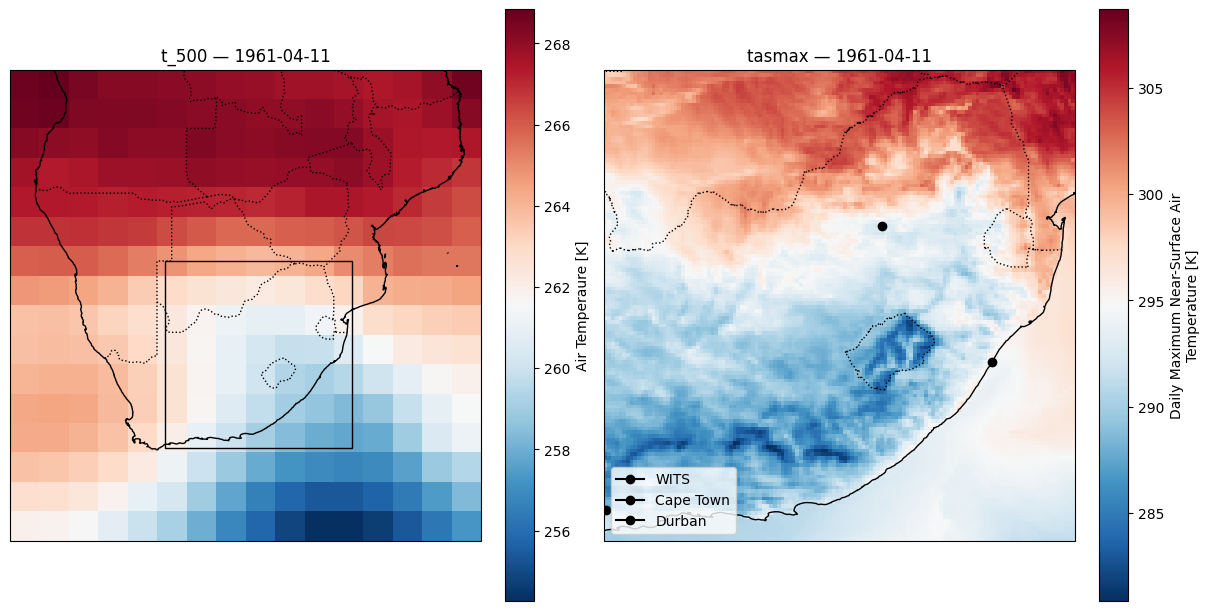

In [4]:
def plot_predictor_and_target(
    ds_pred,
    ds_tgt,
    predictor,
    target,
    time_index=0,
    cmap='viridis',
    pinpoints=None,  # e.g. {"WITS": (-26.19, 28.03), "Cape Town": (-33.93, 18.42)}
):
    tgt_lon = ds_tgt.lon.values
    tgt_lat = ds_tgt.lat.values
    date_str = pd.Timestamp(ds_pred.time.values[time_index]).strftime("%Y-%m-%d")

    fig, axes = plt.subplots(
        1, 2, figsize=(12, 6),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )

    # --- Predictor panel ---
    predictor_to_plot = ds_pred[predictor].isel(time=time_index)
    ax = axes[0]
    predictor_to_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Target domain overlay
    rect = Rectangle(
        (tgt_lon.min(), tgt_lat.min()),
        tgt_lon.max() - tgt_lon.min(),
        tgt_lat.max() - tgt_lat.min(),
        linewidth=1, edgecolor='black', facecolor='none',
    )
    ax.add_patch(rect)
    ax.set_title(f'{predictor} — {date_str}')

    # --- Target panel ---
    target_to_plot = ds_tgt[target].isel(time=time_index)
    ax = axes[1]
    target_to_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Pinpoints
    if pinpoints is not None:
        for label, (lat, lon) in pinpoints.items():
            nearest_lat = float(tgt_lat[abs(tgt_lat - lat).argmin()])
            nearest_lon = float(tgt_lon[abs(tgt_lon - lon).argmin()])
            ax.plot(
                nearest_lon, nearest_lat,
                marker='o', markersize=6, color='black',
                transform=ccrs.PlateCarree(), label=label,
            )
        ax.legend(loc='lower left')

    ax.set_title(f'{target} — {date_str}')
    plt.show()


# Usage
plot_predictor_and_target(
    ds_pred, ds_tgt,
    predictor='t_500',
    target='tasmax',
    time_index=100,
    cmap='RdBu_r',
    pinpoints={
        "WITS":      (-26.19, 28.03),
        "Cape Town": (-33.93, 18.42),
        "Durban":    (-29.86, 31.02),
    },
)

In [5]:
# Select years for training and validation (does not need to be consecutive years)
train_years = [
    *range(1961,1967),
    *range(1968,1975),
    *range(1976,1979),
    *range(2081,2087),
    *range(2088,2095),
    *range(2096,2099),
]
val_years = [1967, 1975, 2087, 2095]
test_years = [1979, 1980, 2080, 2099]

In [6]:
# Specify directory where training and validation data will be stord
train_dir = pathlib.Path('/gws/nopw/j04/mohc_shared/users/jar212/cordexbench/train')
train_dir.mkdir(parents=True, exist_ok=True)

predictors_train_data_path = train_dir / 'predictors_train.nc'
predictors_val_data_path = train_dir / 'predictors_val.nc'
predictors_test_data_path = train_dir / 'predictors_test.nc'
targets_train_data_path = train_dir / 'targets_train.nc'
targets_val_data_path = train_dir / 'targets_val.nc'
targets_test_data_path = train_dir / 'targets_test.nc'

In [7]:
# Specify directory where outputs will be stored (normalisation stats, alphas, betas, model)
output_dir = pathlib.Path('/gws/nopw/j04/mohc_shared/users/jar212/cordexbench/outputs')
output_dir.mkdir(parents=True, exist_ok=True)

normalisation_stats_path = output_dir / 'normalisation_stats.json'

In [8]:
# Split predictors and target datasets into train and val splits

def split_by_year(ds, years):
    return ds.sel(time=ds['time'].dt.year.isin(years))

ds_pred_train = split_by_year(ds_pred, train_years)
ds_pred_val = split_by_year(ds_pred, val_years)
ds_pred_test = split_by_year(ds_pred, test_years)
ds_tgt_train = split_by_year(ds_tgt, train_years)
ds_tgt_val = split_by_year(ds_tgt, val_years)
ds_tgt_test = split_by_year(ds_tgt, test_years)

ds_pred_train.to_netcdf(predictors_train_data_path)
ds_pred_val.to_netcdf(predictors_val_data_path)
ds_pred_test.to_netcdf(predictors_test_data_path)
ds_tgt_train.to_netcdf(targets_train_data_path)
ds_tgt_val.to_netcdf(targets_val_data_path)
ds_tgt_test.to_netcdf(targets_test_data_path)

ds_pred.close()
ds_tgt.close()

In [75]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda:0


In [76]:
# Select predictors and targets
predictors_selection = [
    'u_500', 'v_500', 'q_500', 't_500', 'z_500',
    'u_700', 'v_700', 'q_700', 't_700', 'z_700',
    'u_850', 'v_850', 'q_850', 't_850', 'z_850',
]
target_selection = ['pr']

In [77]:
training_dataset = CORDEXDataset(
    predictors_data_path=predictors_train_data_path,
    predictors=predictors_selection,
    target=target_selection,
    normalisation_stats_path=normalisation_stats_path,
    targets_data_path=targets_train_data_path,
    is_train=True,
)

validation_dataset = CORDEXDataset(
    predictors_data_path=predictors_val_data_path,
    predictors=predictors_selection,
    target=target_selection,
    normalisation_stats_path=normalisation_stats_path,
    targets_data_path=targets_val_data_path,
    is_train=False,
)

print(f"Training samples:       {len(training_dataset)}")
print(f"Validation samples:     {len(validation_dataset)}")
print(f"2D predictors:          {training_dataset.num_2d_predictors}")
print(f"1D predictors:          {training_dataset.num_1d_predictors}")
print(f"Predictor grid shape:   {training_dataset.normalised_two_d_predictors.shape[2:]}")
print(f"Target grid shape:      {training_dataset.target_field.shape[2:]}")

Training samples:       11680
Validation samples:     1460
2D predictors:          15
1D predictors:          32
Predictor grid shape:   (16, 16)
Target grid shape:      (128, 128)


In [78]:
# Hyper Parameters
batch_size = 32
model_channels = 64
channel_mult = [1, 2, 4, 8, 8]
loss = 'emulasym'
optimiser_type = 'adam'
learning_rate = 5e-4
scheduler_type = 'onecycle'
epochs = 10

scheduler_step_size = 10
scheduler_gamma = 0.1
scheduler_max_lr = 5e-4

input_resolution = 16
output_resolution = 128
output_channels = len(target_selection)
num_2d_predictors = training_dataset.num_2d_predictors
num_1d_predictors = training_dataset.num_1d_predictors

In [79]:
training_dataloader = torch.utils.data.DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
validation_dataloader = torch.utils.data.DataLoader(validation_dataset, batch_size=batch_size)

In [80]:
class ConvBlock(nn.Module):
    """Convolutional block with two convolutional layers and batch normalisation."""

    def __init__(self, in_ch: int, out_ch: int):
        """Initialise the ConvBlock.

        Args:
            in_ch: Number of input channels.
            out_ch: Number of output channels
        """
        kernel_size = 3
        stride = 1
        padding = 1

        super().__init__()

        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor. Shape: (batch_size, in_ch, h, w)

        Returns:
            Output tensor. Shape: (batch_size, out_ch, h, w)
        """
        return self.model(x)

In [81]:
class ConvTransposeBlock(nn.Module):
    """Transposed convolutional block with a convolutional layer, batch normalisation and ReLU.

    The transposed convolutional layer doubles the spatial dimensions of the input.
    """

    def __init__(self, in_ch: int, out_ch: int):
        """Initialise the ConvTransposeBlock.

        Args:
            in_ch: Number of input channels.
            out_ch: Number of output channels.
        """
        kernel_size = 3
        stride = 2
        padding = 1
        output_padding = 1

        super().__init__()

        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size, stride, padding, output_padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor. Shape: (batch_size, in_ch, h, w)

        Returns:
            Output tensor. Shape: (batch_size, out_ch, 2*h, 2*w)
        """
        return self.model(x)

In [82]:
class Conv1x1(nn.Module):
    """1x1 convolutional layer with ReLU activation."""

    def __init__(self, in_ch: int, out_ch: int):
        """Initialise the Conv1x1 layer.

        Args:
            in_ch: Number of input channels.
            out_ch: Number of output channels
        """
        kernel_size = 1
        stride = 1
        padding = 0

        super().__init__()

        self.layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
            nn.ReLU(),
        ]
        self.model = nn.Sequential(*self.layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor. Shape: (batch_size, in_ch, h, w)

        Returns:
            Output tensor. Shape: (batch_size, out_ch, h, w)
        """
        return self.model(x)

In [83]:
class DownBlock(nn.Module):
    """Downsampling block.

    Uses a max pooling layer to half the spatial dimensions of the input.
    """

    def __init__(self, in_ch: int, out_ch: int):
        """Initialise the DownBlock.

        Args:
            in_ch: Number of input channels.
            out_ch: Number of output channels.
        """
        kernel_size = 3
        stride = 1
        padding = 1

        super().__init__()

        layers = [
            nn.MaxPool2d(2),
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor. Shape: (batch_size, in_ch, h, w)

        Returns:
            Output tensor. Shape: (batch_size, out_ch, h/2, w/2)
        """
        return self.model(x)

In [84]:
class UpBlock(nn.Module):
    """Upsampling block.

    Uses bilinear upsampling followed by a regular convolution to double the spatial
    dimensions of the input. This avoids the checkerboard artefacts that can occur
    with transposed convolutions.
    """

    def __init__(self, in_ch: int, out_ch: int):
        """Initialise the UpBlock.

        Args:
            in_ch: Number of input channels.
            out_ch: Number of output channels. Must be half the number of input channels.

        Raises:
            ValueError: If the number of output channels is not half the number of input channels.
        """
        if out_ch != in_ch / 2:
            raise ValueError("Number of output channels must be half the number of input channels")

        kernel_size = 3
        padding = 1

        super().__init__()

        upsample_layers = [
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        ]
        self.upsample = nn.Sequential(*upsample_layers)

        conv_layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        ]
        self.conv = nn.Sequential(*conv_layers)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor, shape (batch, in_ch, h, w).
            skip: Skip connection from the corresponding DownBlock,
                shape (batch, in_ch / 2, h*2, w*2).

        Returns:
            Output tensor, shape (batch, in_ch / 2, h*2, w*2).
        """
        x = self.upsample(x)
        x = torch.cat((x, skip), dim=1)
        x = self.conv(x)
        return x

In [85]:
# class UpBlock(nn.Module):
#     """Upsampling block.

#     Uses a transposed convolutional layer to double the spatial dimensions of the input.
#     """

#     def __init__(self, in_ch: int, out_ch: int):
#         """Initialise the UpBlock.

#         Args:
#             in_ch: Number of input channels.
#             out_ch: Number of output channels. This is required to be half the number of input
#                 channels.

#         Raises:
#             ValueError: If the number of output channels is not half the number of input channels.
#         """
#         if out_ch != in_ch / 2:
#             raise ValueError("Number of output channels must be half the number of input channels")

#         # Convolution variables
#         kernel_size = 3
#         stride = 1
#         padding = 1

#         # Transposed convolution variables
#         strideT = 2
#         out_paddingT = 1

#         super().__init__()

#         convT_layers = [
#             nn.ConvTranspose2d(in_ch, out_ch, kernel_size, strideT, padding, out_paddingT),
#             nn.BatchNorm2d(out_ch),
#             nn.ReLU(),
#         ]
#         self.convT = nn.Sequential(*convT_layers)

#         conv_layers = [
#             nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
#             nn.BatchNorm2d(out_ch),
#             nn.ReLU(),
#         ]
#         self.conv = nn.Sequential(*conv_layers)

#     def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
#         """Forward pass.

#         Args:
#             x: Input tensor. Shape: (batch_size, in_ch, h, w)
#             skip: Skip connection tensor. Typically an output from a downsampling block.
#                 Shape: (batch_size, in_ch / 2, h*2, w*2)

#         Returns:
#             Output tensor. Shape: (batch_size, in_ch / 2, h*2, w*2)
#         """
#         x = self.convT(x)
#         x = torch.cat((x, skip), dim=1)
#         x = self.conv(x)
#         return x

In [86]:
class FullyConnectedBlock(nn.Module):
    """Block with four fully connected layers."""

    def __init__(self, in_features: int, out_features: int):
        """Initialise the FullyConnectedBlock.

        Args:
            in_features: Number of input features.
            out_features: Number of output features.
        """
        super().__init__()

        layers = [
            nn.Linear(in_features, 64),
            nn.Linear(64, 128),
            nn.Linear(128, 256),
            nn.Linear(256, out_features),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Tensor of shape (batch_size, in_features)

        Returns:
            Tensor of shape (batch_size, out_features)
        """
        return self.model(x)

In [87]:
class UNet(nn.Module):
    """U-net model."""

    def __init__(
        self,
        num_2d_predictors: int,
        num_1d_predictors: int,
        model_channels: int = 64,
        channel_mult: list[int] = [1, 2, 4, 8, 8],
        input_resolution: int = 16,
        output_resolution: int = 64,
        output_channels: int = 1,
    ):
        """Initialise the U-net model.

        Args:
            num_2d_predictors: Number of 2D predictor fields.
            num_1d_predictors: Number of 1D predictor features.
            model_channels: Base multiplier for the number of channels.
            channel_mult: Per-resolution multipliers for the number of channels. These must
                increase by a factor of 2 for each resolution level, except for the last
                resolution level which must be the same as the previous one.
            input_resolution: Resolution of the input data.
            output_resolution: Required resolution of the output. The ratio
                output_resolution/input_resolution must be a power of 2. If the output resolution
                differs from the input resolution, then a sequence of convolution and transposed
                convolution blocks will be used to upsample the output from the decoder to the
                required output resolution. Doury et al (2022) uses input_resolution=16 and
                output_resolution=128.
            output_channels: Required number of channels in the output.

        Raises:
            ValueError: If output_resolution isn't a multiple of resolution.
        """
        super().__init__()
        channels = [model_channels * mult for mult in channel_mult]

        # MLP embedding for the 1D predictors
        self.embedding = FullyConnectedBlock(
            in_features=num_1d_predictors, out_features=channels[-1]
        )

        # Encoder
        self.encoder = torch.nn.ModuleDict()
        #logger.info("Encoder:")
        for level, num_channels in enumerate(channels):
            res = input_resolution >> level  # Equivalent to input_resolution // (2 ** level)
            if level == 0:
                in_ch = num_2d_predictors
                out_ch = num_channels
                #logger.info(f"Input channels: {in_ch}, Output_channels: {out_ch}")
                self.encoder[f"{res}x{res}_conv"] = nn.Sequential(
                    ConvBlock(in_ch, int(out_ch / 2)), ConvBlock(int(out_ch / 2), out_ch)
                )
            else:
                in_ch = out_ch
                out_ch = num_channels
                self.encoder[f"{res}x{res}_down"] = DownBlock(in_ch, out_ch)
            #logger.info(
                #f"Level {level}, Input channels: {in_ch}, Output channels: {out_ch}, Output resolution: {res}x{res}"
            #)

        if res != 1:
            raise ValueError(f"Bottleneck layer must be 1x1 spatially. Got {res}x{res}")

        # Decoder
        self.decoder = torch.nn.ModuleDict()
        #logger.info("\nDecoder:")
        for level, num_channels in reversed(list(enumerate(channels[:-1]))):
            res = input_resolution >> level
            in_ch = num_channels * 2
            out_ch = num_channels
            self.decoder[f"{res}x{res}_up"] = UpBlock(in_ch, out_ch)
            #logger.info(
                #f"Level {level}, Input channels: {in_ch}, Output channels: {out_ch}, Output resolution: {res}x{res}"
            #)

        # Upsample output of decoder to required output resolution.
        scale = output_resolution / input_resolution
        if not scale.is_integer():
            raise ValueError("output_resolution must be divisible by resolution")
        scale = int(scale)
        if scale & (scale - 1) != 0:  # Check if scale is a power of 2
            raise ValueError("output_resolution/resolution must be a power of 2")
        num_upsample_steps = int(log2(scale))

        upsample_layers: list[nn.Module] = []
        for _ in range(num_upsample_steps):
            upsample_layers.append(ConvTransposeBlock(in_ch=channels[0], out_ch=channels[0]))
            upsample_layers.append(ConvBlock(in_ch=channels[0], out_ch=channels[0]))
        upsample_layers.append(Conv1x1(in_ch=channels[0], out_ch=output_channels))
        self.upsample = nn.Sequential(*upsample_layers)

    def forward(self, two_d_fields: torch.Tensor, one_d_features: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            two_d_fields: 2D predictor fields. Shape (batch_size, num_2d_predictors, h, w).
            one_d_features: 1D predictor features. Shape (batch_size, num_1d_predictors).

        Returns:
            x: Predicted 2D field. Shape (batch_size, output_channels, output_resolution, output_resolution)
        """
        x = two_d_fields

        # Encoder
        skips = []
        for idx, block in enumerate(self.encoder.values()):
            x = block(x)
            if idx < len(self.encoder) - 1:
                skips.append(x)

        embedded_1d_features = self.embedding(one_d_features)  # shape: (batch_size, C)
        # Assumes bottleneck layer is 1x1 spatially
        embedded_1d_features = embedded_1d_features[
            :, :, None, None
        ]  # shape: (batch_size, C, 1, 1)

        x = torch.cat((x, embedded_1d_features), dim=1)  # shape: (batch_size, C*2, 1, 1)

        # Decoder
        for block in self.decoder.values():
            x = block(x, skips.pop())

        # Upsample output of encoder-decoder to required output resolution
        x = self.upsample(
            x
        )  # shape: (batch_size, output_channels, output_resolution, output_resolution)

        return x

In [88]:
model = UNet(
    num_2d_predictors=num_2d_predictors,
    num_1d_predictors=num_1d_predictors,
    model_channels=model_channels,
    channel_mult=channel_mult,
    input_resolution=input_resolution,
    output_resolution=output_resolution,
    output_channels=output_channels,
).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

Model parameters: 22,489,441


In [89]:
def fit_gamma_distributions(
    precip_data: np.ndarray,
    time: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Fit gamma distributions to precipitation data, one per grid cell.

    A gamma distribution is fitted to the wet-day precipitation (> 1mm) for each
    grid cell. Distributions are fitted independently for each year and the resulting
    alpha and beta parameters are averaged over all years.

    Grid cells with no wet days in a given year are assigned shape=1, scale=1
    (an exponential distribution), which acts as a neutral fallback.

    Years with fewer than 360 samples are skipped, as an incomplete year would bias
    the fitted distributions.

    Note: fitting is performed in a grid-cell loop because scipy.stats.gamma.fit
    does not support vectorised fitting across multiple samples simultaneously.

    Args:
        precip_data: Precipitation data, shape (samples, lat, lon), in mm/day.
        time: Time coordinates, shape (samples,).

    Returns:
        alphas: Alpha (shape) parameters for each grid cell, shape (lat, lon).
        betas: Beta (scale) parameters for each grid cell, shape (lat, lon).
    """
    num_lat, num_lon = precip_data.shape[1], precip_data.shape[2]
    alpha_grids: list[np.ndarray] = []
    beta_grids: list[np.ndarray] = []

    years = np.unique([t.year for t in time])
    for year in years:
        idxs = np.where([t.year == year for t in time])[0]
        if len(idxs) < 360:
            warnings.warn(
                f"Skipping year {year}: only {len(idxs)} samples available (expected >= 360)."
            )
            continue

        samples = precip_data[idxs]  # (days_in_year, lat, lon)
        alpha_grid = np.zeros((num_lat, num_lon))
        beta_grid = np.zeros((num_lat, num_lon))

        for i in range(num_lat):
            for j in range(num_lon):
                data = samples[:, i, j]
                data = data[data > 1]
                if len(data) == 0:
                    alpha_grid[i, j] = 1.0
                    beta_grid[i, j] = 1.0
                else:
                    shape, _, scale = gamma.fit(data, floc=0)
                    alpha_grid[i, j] = shape
                    beta_grid[i, j] = scale

        alpha_grids.append(alpha_grid)
        beta_grids.append(beta_grid)

    alphas = np.mean(alpha_grids, axis=0)
    betas = np.mean(beta_grids, axis=0)
    return alphas, betas

In [90]:
class EmulASYMLoss(torch.nn.Module):
    """Asymmetric loss function for precipitation downscaling.

    Combines MAE with an asymmetric penalty term that increasingly penalises
    underprediction of heavy rainfall events. The penalty is weighted by the
    squared gamma CDF of the target value, so rare high-rainfall events incur
    a much larger penalty than common low-rainfall days.

    The gamma CDF is evaluated on physical precipitation values (mm/day), so
    inputs and targets are denormalised internally before computing the asymmetric
    term. The MAE is computed in normalised space, consistent with how MSE/MAE
    losses operate during training.

    Total loss = MAE(normalised) + mean(CDF(target_mm/day)^2 * max(0, target - prediction))
    """

    def __init__(
        self,
        alphas: torch.Tensor | np.ndarray,
        betas: torch.Tensor | np.ndarray,
        pr_channel_idx: int,
    ):
        """Initialise EmulASYM loss.

        Args:
            alphas: Gamma shape parameters per grid cell, shape (lat, lon).
            betas: Gamma scale parameters per grid cell, shape (lat, lon).
            pr_channel_idx: Index of the pr channel in the target tensor.
            pr_norm_mean: Mean used to normalise pr during dataset construction
                (after log1p transform).
            pr_norm_std: Std used to normalise pr during dataset construction
                (after log1p transform).
        """
        super().__init__()
        if isinstance(alphas, np.ndarray):
            alphas = torch.from_numpy(alphas).float()
        if isinstance(betas, np.ndarray):
            betas = torch.from_numpy(betas).float()
        # Register as buffers so they are moved to the correct device with .to(DEVICE)
        # and included in state_dict for checkpointing.
        self.register_buffer("alphas", alphas)
        self.register_buffer("betas", betas)
        self.pr_channel_idx = pr_channel_idx

    def forward(self, input: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """Compute EmulASYM loss.

        Args:
            input: Predicted field, shape (batch, channels, lat, lon).
            target: Target field, shape (batch, channels, lat, lon).

        Returns:
            Scalar loss tensor.
        """
        mae_loss = F.l1_loss(input, target)

        # Extract pr channel and denormalise to mm/day for CDF evaluation
        pr_input  = input[:, self.pr_channel_idx, :, :]   # (batch, lat, lon)
        pr_target = target[:, self.pr_channel_idx, :, :]  # (batch, lat, lon)

        gamma_cdf = torch.special.gammainc(self.alphas, pr_target / self.betas)
        asym_loss = (gamma_cdf ** 2 * torch.clamp(pr_target - pr_input, min=0)).mean()

        return mae_loss + asym_loss



In [91]:
if loss == "mse":
    loss_fn = torch.nn.MSELoss()
elif loss == "mae":
    loss_fn = torch.nn.L1Loss()
elif loss == "emulasym":
    if "pr" not in target_selection:
        raise ValueError(
            "EmulASYM loss requires 'pr' to be in target_selection."
        )
    # Fit gamma distributions on raw (un-normalised) precipitation in mm/day.
    # This must be done from the source netCDF, not training_dataset.target_field,
    # which has already been log1p normalised.
    with xr.open_dataset(targets_train_data_path) as ds_tgt_train:
        precip_data = ds_tgt_train["pr"].values  # (samples, lat, lon)
    alphas, betas = fit_gamma_distributions(precip_data, training_dataset.time)
    np.save(output_dir / 'alphas.npy', alphas)
    np.save(output_dir / 'betas.npy', betas)

    pr_channel_idx = target_selection.index("pr")
    loss_fn = EmulASYMLoss(
        alphas=alphas,
        betas=betas,
        pr_channel_idx=pr_channel_idx,
    ).to(DEVICE)
else:
    raise ValueError(
        f"Invalid loss function '{loss}'. Must be one of 'mse', 'mae', 'emulasym'."
    )


In [92]:
# Optimiser selection
if optimiser_type.lower() == "adam":
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
elif optimiser_type.lower() == "sgd":
    optimiser = torch.optim.SGD(model.parameters(), lr=learning_rate)
else:
    raise ValueError(f"Unsupported optimiser: {optimiser_type}")

In [93]:
# Scheduler selection
if scheduler_type.lower() == "onecycle":
    scheduler = OneCycleLR(
        optimiser,
        max_lr=scheduler_max_lr,
        steps_per_epoch=len(training_dataloader),
        epochs=epochs,
    )
elif scheduler_type.lower() == "steplr":
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimiser,
        step_size=scheduler_step_size,
        gamma=scheduler_gamma,
    )
else:
    raise ValueError(f"Unsupported scheduler: {scheduler_type}")

In [94]:
def train_loop(
    dataloader: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler,
    device: torch.device,
    epoch: int,
    scheduler_type: str = "onecycle",
):
    """Training loop for a single epoch.

    Runs the training loop for a single epoch. Metrics are logged to MLflow.

    Args:
        dataloader: DataLoader for the training data.
        model: The model to train.
        loss_fn: The loss function.
        optimizer: The optimizer.
        scheduler: The learning rate scheduler.
        device: The device to run the training on.
        epoch: The current epoch.
        scheduler_type: Type of scheduler ('onecycle' or 'steplr').
    """
    num_samples = len(dataloader.dataset)
    num_batches = len(dataloader)

    # Set the model to training mode.
    model.train()

    for batch_idx, (two_d_predictors, one_d_predictors, target, _) in enumerate(dataloader):
        # Move data to the device.
        two_d_predictors = two_d_predictors.to(device)
        one_d_predictors = one_d_predictors.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        # Forward pass.
        output = model(two_d_predictors, one_d_predictors)

        # Compute the loss.
        loss = loss_fn(output, target)

        # Backward pass.
        loss.backward()

        # Update the weights.
        optimizer.step()

        # The learning rate for OneCycleLR should be stepped after each batch. 
        if scheduler_type.lower() == "onecycle":
            scheduler.step()

        if batch_idx % 100 == 0:
            loss = loss.item()
            current = batch_idx * len(two_d_predictors)
            print(f"loss: {loss:>7f}  [{current:>5d}/{num_samples:>5d}]")
            batch_number = (epoch * num_batches) + batch_idx
            mlflow.log_metric("Training loss", loss, step=batch_number)
            mlflow.log_metric("learning rate", scheduler.get_last_lr()[0], step=batch_number)

    # Step the learning rate for StepLR only (once per epoch)
    if scheduler_type.lower() == "steplr":
        scheduler.step()

In [95]:
def test_loop(
    dataloader: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    loss_fn: torch.nn.Module,
    device: torch.device,
    epoch: int,
) -> float:
    """Validation loop.

    Iterates over the validation/test data, computes predictions and loss.

    Args:
        dataloader: DataLoader for the validation/test data.
        model: The model to evaluate.
        loss_fn: The loss function.
        device: The device to run the evaluation on.
        epoch: The current epoch.

    Returns:
        The average loss over the validation/test dataset.
    """
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0

    with torch.no_grad():
        for two_d_predictors, one_d_predictors, target, _ in dataloader:
            # Move data to the device.
            two_d_predictors = two_d_predictors.to(device)
            one_d_predictors = one_d_predictors.to(device)
            target = target.to(device)

            # Forward pass.
            output = model(two_d_predictors, one_d_predictors)

            # Compute the loss.
            loss = loss_fn(output, target)
            loss = loss.item()

            test_loss += loss

    test_loss /= num_batches

    print(f"\nValidation loss: {test_loss:>7f}\n")
    mlflow.log_metric("Validation loss", test_loss, step=epoch + 1)

    return test_loss

In [ ]:
best_val_loss = np.inf
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_loop(
        training_dataloader, model, loss_fn, optimiser, scheduler, DEVICE, epoch, scheduler_type
    )

    val_loss = test_loop(validation_dataloader, model, loss_fn, DEVICE, epoch)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

    if scheduler is not None:
        print(f"Current learning rate: {scheduler.get_last_lr()[0]}")

    # log_prediction_visualisation(model, validation_dataset, DEVICE, epoch, predictors, targets) # ADD THIS LATER

Epoch 1
-------------------------------
loss: 4.704527  [    0/11680]
loss: 5.029038  [ 3200/11680]
loss: 3.787799  [ 6400/11680]
loss: 2.977208  [ 9600/11680]

Validation loss: 5.004612

Current learning rate: 0.00014019900917212663
Epoch 2
-------------------------------
loss: 3.835609  [    0/11680]
loss: 6.089611  [ 3200/11680]
loss: 3.872751  [ 6400/11680]
loss: 3.921212  [ 9600/11680]


In [ ]:
model_path = output_dir / 'model.pth'
print(f"Training complete. Saving model to {model_path}")
torch.save(best_model_state, model_path)

In [ ]:
model = UNet(
    num_2d_predictors=num_2d_predictors,
    num_1d_predictors=num_1d_predictors,
    model_channels=model_channels,
    channel_mult=channel_mult,
    input_resolution=input_resolution,
    output_resolution=output_resolution,
    output_channels=output_channels,
).to(DEVICE)
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

In [ ]:
inference_dataset = CORDEXDataset(
    predictors_data_path=predictors_test_data_path,
    predictors=predictors_selection,
    target=target_selection,
    normalisation_stats_path=normalisation_stats_path,
    targets_data_path=targets_test_data_path,
    is_train=False,
)

In [ ]:
inference_dataloader = torch.utils.data.DataLoader(inference_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [ ]:
predictions = []
targets = []
times = []

In [ ]:
# Make predictions over the dataset.
with torch.no_grad():
    for two_d_predictors, one_d_predictors, target_field, time in inference_dataloader:
        two_d_predictors = two_d_predictors.to(DEVICE)  # shape: (batch_size, num_2d_predictors, lat, lon)
        one_d_predictors = one_d_predictors.to(DEVICE)  # shape: (batch_size, num_1d_predictors)

        prediction = model(two_d_predictors, one_d_predictors)  # shape: (batch_size, channels, lat, lon)

        predictions.append(prediction.cpu().numpy())
        targets.append(target_field.cpu().numpy())
        times.extend(time)  # time is a list of strings "YYYY-MM-DD", of length batch_size


In [ ]:
predictions = np.concatenate(predictions, axis=0)  # Shape: (num_samples, 1,  lat, lon)
targets = np.concatenate(targets, axis=0)  # Shape: (num_samples, 1, lat, lon)
times = pd.to_datetime(times)  # Shape: (num_samples,)

In [ ]:
# Denormalise to physical units (Celsius for tasmax, mm/day for pr)
predictions_physical = inference_dataset.denormalise(predictions)
targets_physical     = inference_dataset.denormalise(targets)

In [ ]:
# Store each target variable as its own data variable, matching the
# convention used in the input netCDF files.
data_vars = {}
for ch_idx, name in enumerate(target_selection):
    data_vars[f"{name}_pred"] = (
        ["time", "lat", "lon"],
        predictions_physical[:, ch_idx, :, :],
    )
    data_vars[f"{name}_target"] = (
        ["time", "lat", "lon"],
        targets_physical[:, ch_idx, :, :],
    )

ds_predictions = xr.Dataset(
    data_vars,
    coords={
        "time": times,
        "lat":  inference_dataset.grid_latitude_tgt.values,
        "lon":  inference_dataset.grid_longitude_tgt.values,
    },
)
ds_predictions.attrs["description"] = (
    f"UNet downscaling predictions. "
    f"Predictors: {predictors_selection}. "
    f"Targets: {target_selection}."
)

print(ds_predictions)

output_file = output_dir / "predictions.nc"
ds_predictions.to_netcdf(output_file, format="NETCDF4", engine="netcdf4")
print(f"Predictions saved to {output_file}")

In [ ]:
def plot_timeseries_for_year(
    ds_predictions,
    year: int,
    target: str,
    pinpoints: dict,  # e.g. {"WITS": (-26.19, 28.03), "Cape Town": (-33.93, 18.42)}
):
    """Plot predicted vs target time series for a given year at multiple locations.

    Args:
        ds_predictions: xarray Dataset with variables {target}_pred and {target}_target.
        year: Year to plot. Must be present in ds_predictions.time.
        target: Target variable to plot, e.g. "pr" or "tasmax".
        pinpoints: Dict mapping location name to (lat, lon) tuple.
    """
    tgt_lat = ds_predictions.lat.values
    tgt_lon = ds_predictions.lon.values

    units = {"pr": "mm/day", "tasmax": "°C"}
    ylabel = units.get(target, target)

    fig, axes = plt.subplots(
        len(pinpoints), 1,
        figsize=(14, 4 * len(pinpoints)),
        sharex=True,
        constrained_layout=True,
    )
    # Ensure axes is always iterable even for a single pinpoint
    if len(pinpoints) == 1:
        axes = [axes]

    for ax, (location, (lat, lon)) in zip(axes, pinpoints.items()):
        nearest_lat = float(tgt_lat[abs(tgt_lat - lat).argmin()])
        nearest_lon = float(tgt_lon[abs(tgt_lon - lon).argmin()])

        ts = ds_predictions.sel(lat=nearest_lat, lon=nearest_lon, time=str(year))

        ax.plot(
            ts.time, ts[f"{target}_target"],
            label="RCM truth", color="black", linewidth=1.0,
        )
        ax.plot(
            ts.time, ts[f"{target}_pred"],
            label="Emulator", color="red", linewidth=1.0,
        )
        ax.set_title(f"{location} ({nearest_lat:.2f}°, {nearest_lon:.2f}°)")
        ax.set_ylabel(ylabel)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Date")
    fig.suptitle(f"{target} — {year}", fontsize=13)
    plt.show()


# Usage
plot_timeseries_for_year(
    ds_predictions,
    year=2099,
    target="tasmax",
    pinpoints={
        "WITS":      (-26.19, 28.03),
        "Cape Town": (-33.93, 18.42),
        "Durban":    (-29.86, 31.02),
    },
)

In [ ]:
def plot_random_day_comparison(
    ds_predictions,
    target: str,
    n_days: int = 3,
    seed: int | None = None,
    cmap: str = "RdBu_r",
):
    """Plot side-by-side RCM truth vs emulator predictions for randomly selected days.

    Args:
        ds_predictions: xarray Dataset with variables {target}_pred and {target}_target.
        target: Target variable to plot, e.g. "pr" or "tasmax".
        n_days: Number of random days to plot.
        seed: Random seed for reproducibility. If None, selection is random.
        cmap: Matplotlib colormap.
    """
    units = {"pr": "mm/day", "tasmax": "°C"}
    unit_label = units.get(target, target)

    vmin = 0 if target == "pr" else None  # precipitation is non-negative; let tasmax float

    if seed is not None:
        np.random.seed(seed)
    all_times = ds_predictions.time.values
    selected_times = np.sort(
        all_times[np.random.choice(len(all_times), size=n_days, replace=False)]
    )

    fig, axes = plt.subplots(
        n_days, 2,
        figsize=(8, 4 * n_days),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )

    for i, t in enumerate(selected_times):
        date_str = np.datetime_as_string(t, unit="D")
        da_target = ds_predictions[f"{target}_target"].sel(time=t)
        da_pred   = ds_predictions[f"{target}_pred"].sel(time=t)

        vmax = float(np.nanmax([da_target.values, da_pred.values]))

        for ax, da, title in zip(
            [axes[i, 0], axes[i, 1]],
            [da_target, da_pred],
            ["RCM truth", "Emulator"],
        ):
            im = da.plot(
                ax=ax, cmap=cmap, transform=ccrs.PlateCarree(),
                vmin=vmin, vmax=vmax, add_colorbar=False,
            )
            ax.coastlines(resolution="10m")
            ax.add_feature(cfeature.BORDERS, linestyle=":")
            ax.set_title(f"{title}\n{date_str}")

        fig.colorbar(im, ax=axes[i, :], orientation="vertical", label=f"{target} ({unit_label})")

    plt.show()


# Usage
plot_random_day_comparison(ds_predictions, target="tasmax", n_days=3, seed=42, cmap="RdBu_r")